# Exploratory Data Analysis
The purpose of this notebook is to explore the dataset.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates

#### 1. Read in the raw dataframe

In [2]:
df = pd.read_parquet(r'..\data\raw\final-raw-merged-data.parquet')

In [3]:
df.head(2)

,date,TMAX,TMIN,AWND,PRCP,BOT_TEMP_C,SURF_TEMP_C
0,1939-07-01,76.0,63.0,NaN,0.0,19.1,19.4
1,1939-07-02,74.0,65.0,NaN,0.0,19.5,19.8


#### 2. Assess for missing values

In [4]:
len(df)

31596

In [5]:
df.isnull().sum()

date               0
TMAX               6
TMIN               6
AWND           16259
PRCP               3
BOT_TEMP_C      1983
SURF_TEMP_C      899
dtype: int64

In [6]:
(df.isnull().mean() * 100).round(1)

date            0.0
TMAX            0.0
TMIN            0.0
AWND           51.5
PRCP            0.0
BOT_TEMP_C      6.3
SURF_TEMP_C     2.8
dtype: float64

AWND has over 50% null values. For that reason it will be dropped from the dataset. This is unfornutate, as wind is a primary driver of upwelling events.

In [7]:
df.drop(columns='AWND', inplace=True)

For the other columns, we will interpolate with the mean of the most adjacent rows for the given column to fill the null.

In [8]:
list(df.columns)

['date', 'TMAX', 'TMIN', 'PRCP', 'BOT_TEMP_C', 'SURF_TEMP_C']

In [9]:
float_cols = ['TMAX', 'TMIN', 'PRCP', 'BOT_TEMP_C', 'SURF_TEMP_C']

df[float_cols] = df[float_cols].interpolate(axis=0)

In [10]:
df.isnull().sum()

date           0
TMAX           0
TMIN           0
PRCP           0
BOT_TEMP_C     0
SURF_TEMP_C    0
dtype: int64

The date column will be split into year, month, and day. For now, month will be used to represent the time of year.

In [11]:
df['month'] = df.date.dt.month.astype(int)
df['day'] = df.date.dt.day.astype(int)
df['year'] = df.date.dt.year.astype(int)

##### save the clean data frame

In [14]:
df.to_parquet('../data/clean-merged-data.parquet',
              engine='pyarrow',
              index=False
              )

#### 3. Individual Variable Analysis

TMAX
count    31596.0
mean        70.7
std          6.8
min         46.0
25%         66.0
50%         70.0
75%         75.0
max        111.0
Name: TMAX, dtype: float64


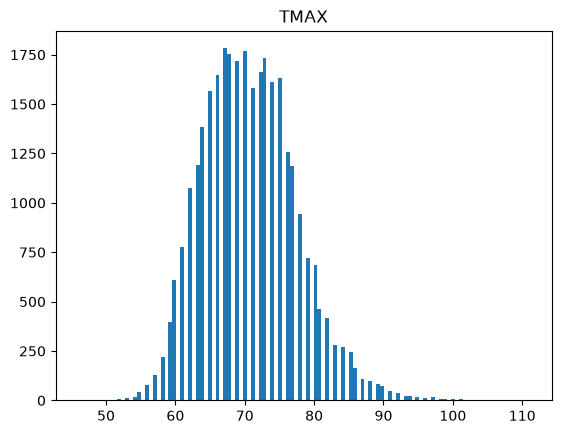

----------

TMIN
count    31596.0
mean        57.3
std          7.4
min         29.0
25%         52.0
50%         58.0
75%         63.0
max         78.0
Name: TMIN, dtype: float64


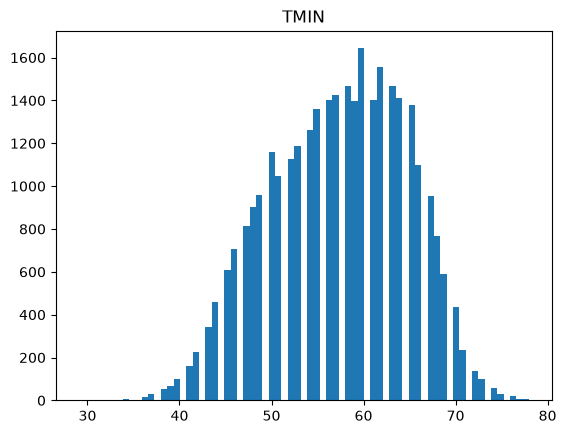

----------

PRCP
count    31596.0
mean         0.0
std          0.1
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          2.7
Name: PRCP, dtype: float64


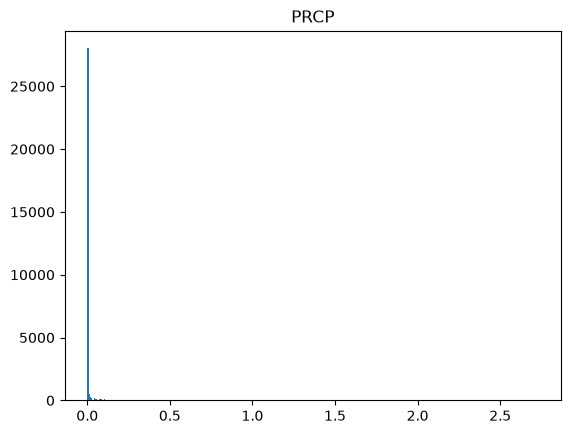

----------

BOT_TEMP_C
count    31596.0
mean        16.8
std          2.4
min         10.0
25%         14.9
50%         16.5
75%         18.5
max         26.0
Name: BOT_TEMP_C, dtype: float64


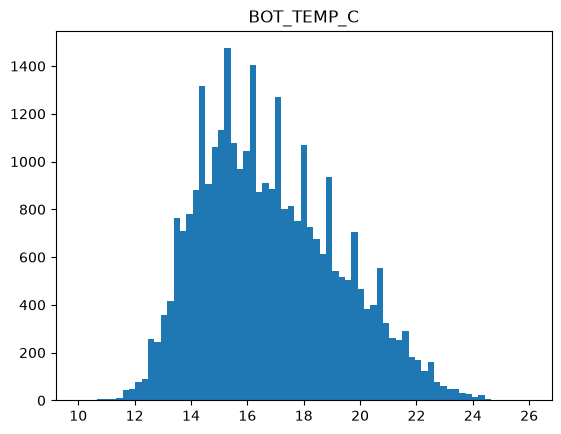

----------

SURF_TEMP_C
count    31596.0
mean        17.4
std          2.7
min         10.1
25%         15.2
50%         17.1
75%         19.4
max         26.4
Name: SURF_TEMP_C, dtype: float64


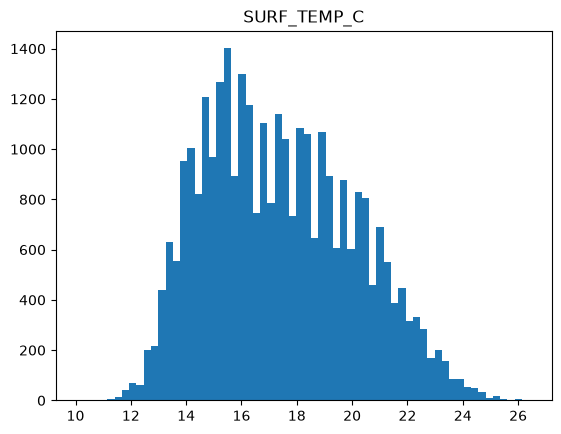

----------



In [12]:
for col in float_cols:
    print(col)
    print(df[col].describe().round(1).T)
    plt.title(col)
    plt.hist(df[col], bins='auto')
    plt.show()

    print('----------\n')


#### Assessing for correlation

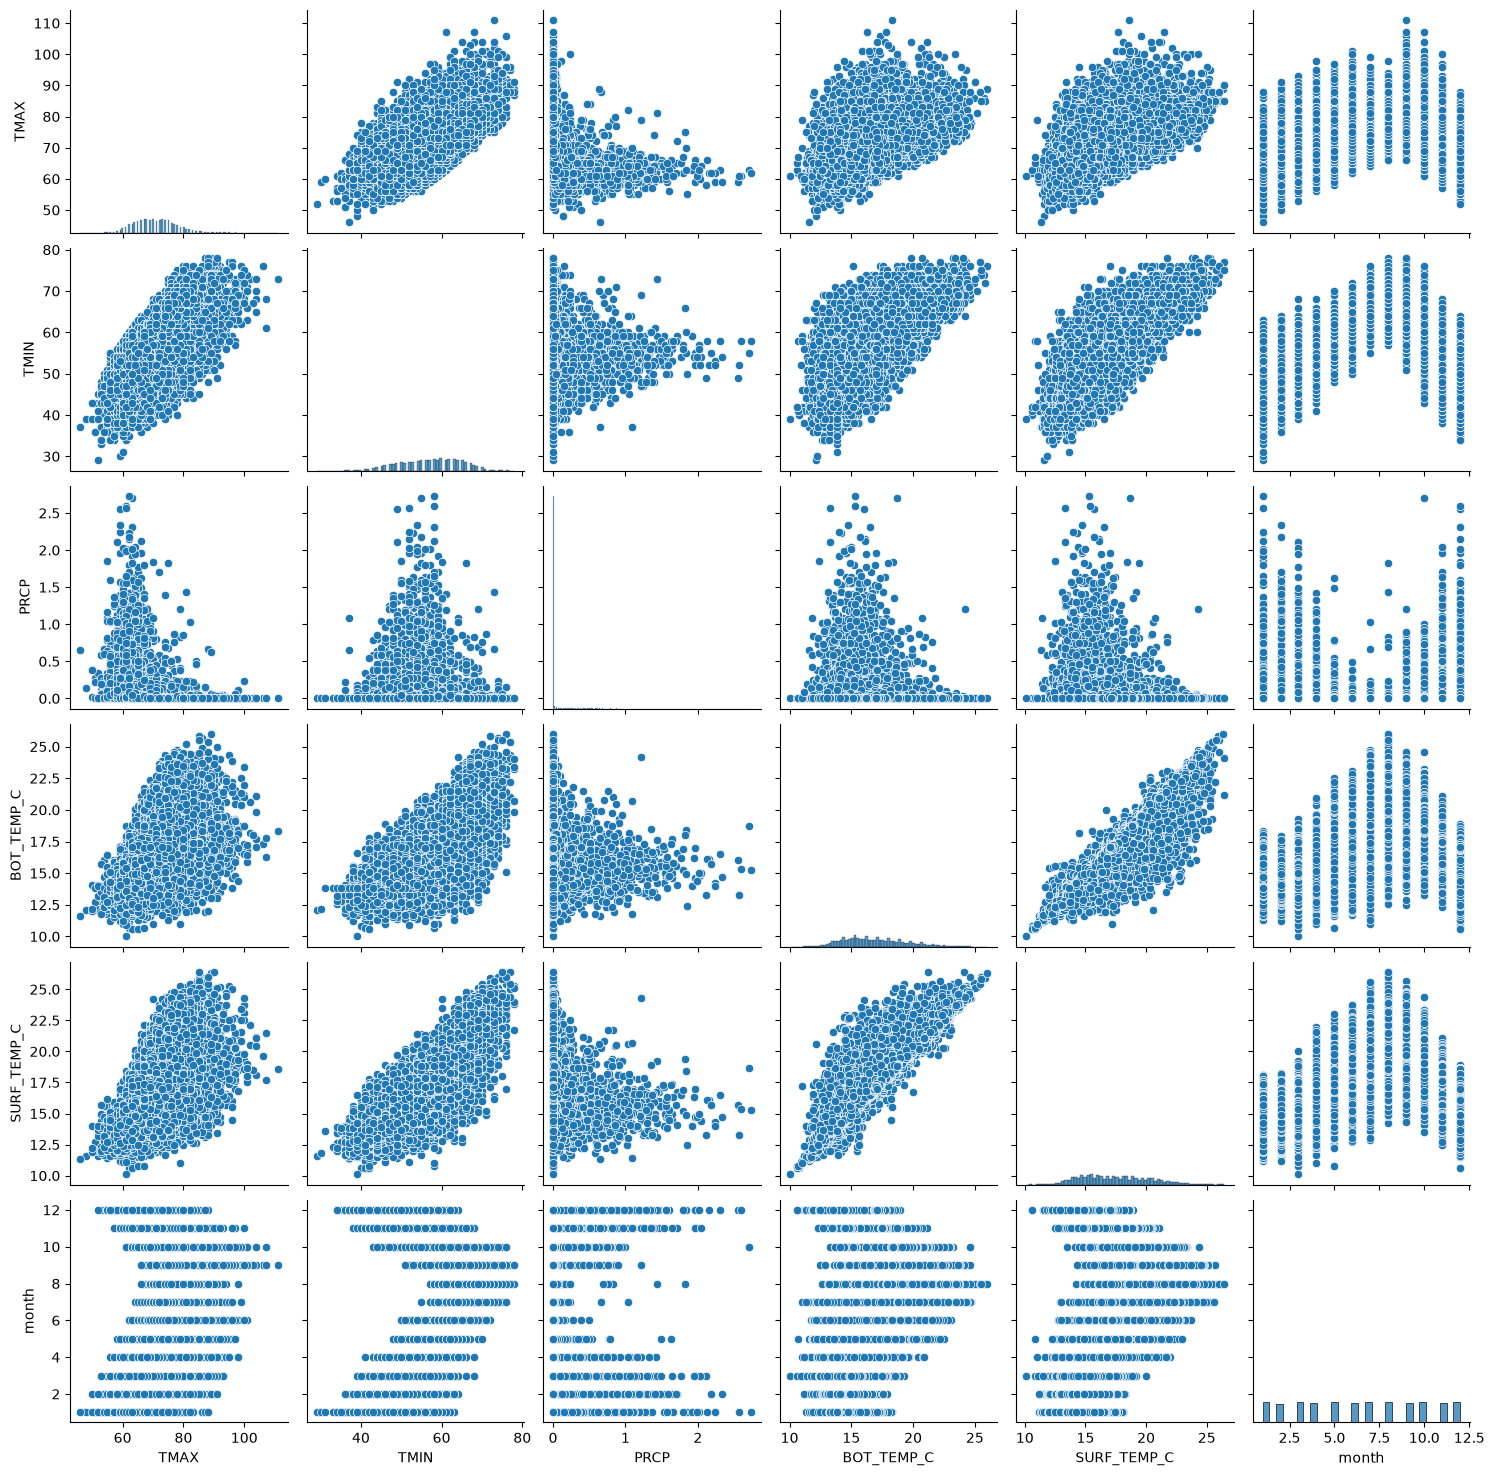

In [15]:
correlation_cols = ['TMAX', 'TMIN', 'PRCP', 'BOT_TEMP_C', 'SURF_TEMP_C', 'month',]
corr_df = df[correlation_cols]
sns.pairplot(corr_df)
plt.show()

In [16]:
corr_matrix = corr_df.corr()
corr_matrix

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month
TMAX,1.000000,0.599508,-0.216343,0.523735,0.619876,0.301396
TMIN,0.599508,1.000000,-0.084774,0.740225,0.837605,0.252952
PRCP,-0.216343,-0.084774,1.000000,-0.108565,-0.133116,-0.062110
BOT_TEMP_C,0.523735,0.740225,-0.108565,1.000000,0.920822,0.363541
SURF_TEMP_C,0.619876,0.837605,-0.133116,0.920822,1.000000,0.381193
month,0.301396,0.252952,-0.062110,0.363541,0.381193,1.000000


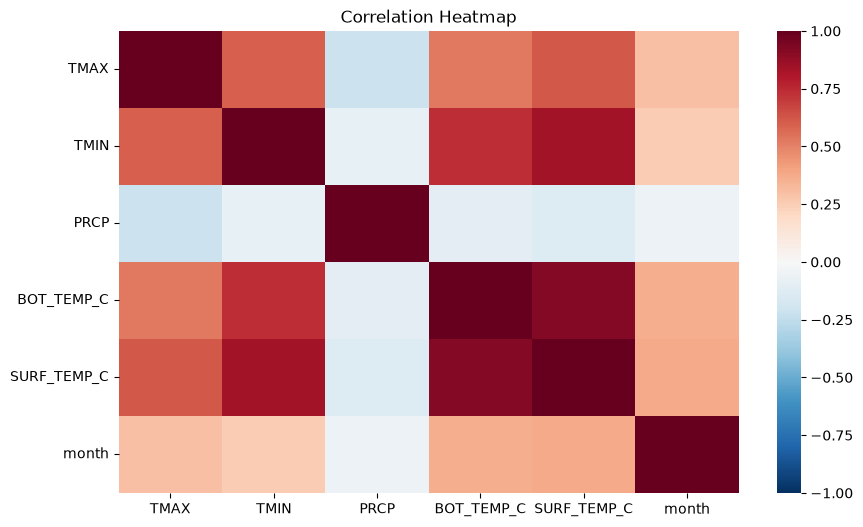

In [17]:
plt.figure(figsize=(10,6))
plt.title('Correlation Heatmap')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            cmap='RdBu_r', 
            fmt=".1f", 
            vmin=-1, 
            vmax=1,
            #mask=mask
            )
plt.show()

Our target variable is SURF_TEMP_C. These two plots are quite telling for what we can expect to impact the water temperature. The month column in the top plot seems to very clearly illustrate, the rise and fall of temperature with the time of the year. The PRCP column appears to have little to no correlation to the water temperature, however with the absense of any wind data, precipitation could be indicative of a weather event coming.

---

In [18]:
def c_to_f(temp_c: float)-> float:
    """
    This function converts from degrees celcius to fahrenheit
    """
    temp_f = (temp_c * (9/5)) + 32

    return temp_f

### Annual Trends

#### By decade

In [105]:
df.year.unique()

array([1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949,
       1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [22]:
df['decade'] = (df.year //10) * 10

In [23]:
df.head(2)

,date,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,decade
184,1940-01-01,67.0,57.0,0.0,16.766667,16.7,1,1,1940,1940
185,1940-01-02,65.0,55.0,0.0,16.833333,16.6,1,2,1940,1940


In [24]:
df['decade'] = df.decade.astype(str) + '\'s'
df.head(2)

,date,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,decade
184,1940-01-01,67.0,57.0,0.0,16.766667,16.7,1,1,1940,1940's
185,1940-01-02,65.0,55.0,0.0,16.833333,16.6,1,2,1940,1940's


In [25]:
df = df[df.year != 1939 ]

In [26]:
decade_temps = df.groupby(['decade', 'month', 'day']).SURF_TEMP_C.mean().reset_index()

In [27]:
decade_temps

,decade,month,day,SURF_TEMP_C
0,1940's,1,1,14.450000
1,1940's,1,2,14.320000
2,1940's,1,3,14.430000
3,1940's,1,4,14.150000
4,1940's,1,5,14.270000
...,...,...,...,...
3289,2020's,12,27,15.425000
3290,2020's,12,28,15.333333
3291,2020's,12,29,15.383333
3292,2020's,12,30,15.508333


In [28]:
decade_temps.month.describe()

count    3294.000000
mean        6.513661
std         3.451758
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        12.000000
Name: month, dtype: float64

In [29]:
decade_temps['mock_year'] = '2000'
decade_temps['mock_dt_str'] = decade_temps.mock_year + '-' + decade_temps.month.astype(str) + '-' + decade_temps.day.astype(str)
decade_temps['mock_date'] = pd.to_datetime(decade_temps.mock_dt_str, format='%Y-%m-%d')

In [30]:
decade_temps.head(2)

,decade,month,day,SURF_TEMP_C,mock_year,mock_dt_str,mock_date
0,1940's,1,1,14.45,2000,2000-1-1,2000-01-01
1,1940's,1,2,14.32,2000,2000-1-2,2000-01-02


In [32]:
print(decade_temps["mock_date"].dt.year.unique())

[2000]


In [33]:
decade_temps['temp_f'] = c_to_f(decade_temps.SURF_TEMP_C)

In [41]:
def create_decade_plot(plot_df):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax2 = ax.twinx()
    for decade, df in plot_df.groupby('decade'):
        ax.plot(df.mock_date, df.SURF_TEMP_C, label=decade)
        ax2.plot(df.mock_date, df.temp_f)
    ax.legend()
    ticks = pd.date_range('2000-01-01', '2000-12-01', freq='MS')
    ax.set_xticks(ticks)
    ax.tick_params(axis='both', labelsize=13)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    fig.autofmt_xdate()
    plt.title('Average Annual Water Temperature by Decade', fontsize=14)
    ax.set_xlabel('Month', fontsize=16)
    ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
    ax2.set_ylabel('(\u00b0F)', fontsize=16)
    ax2.tick_params(axis='y', labelsize=13)
    plt.grid(axis='y', alpha=.5, ls=':')
    plt.show()

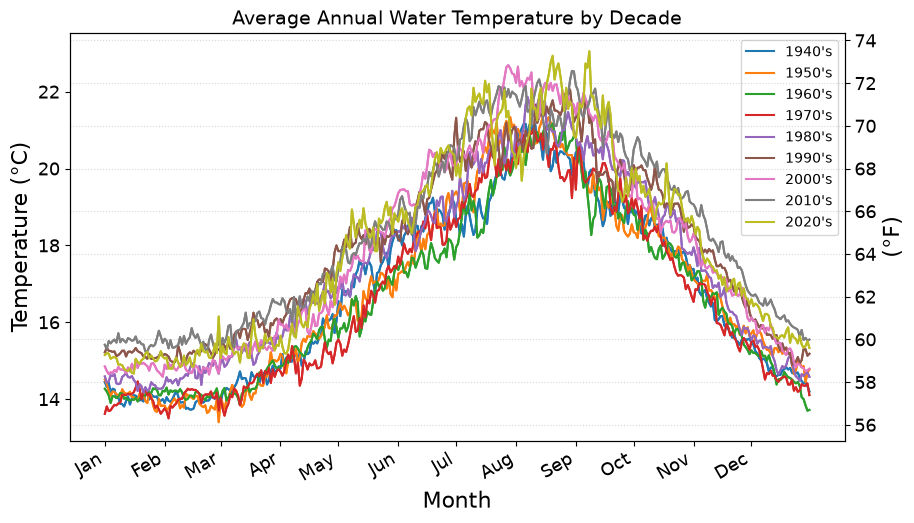

In [42]:
create_decade_plot(decade_temps)

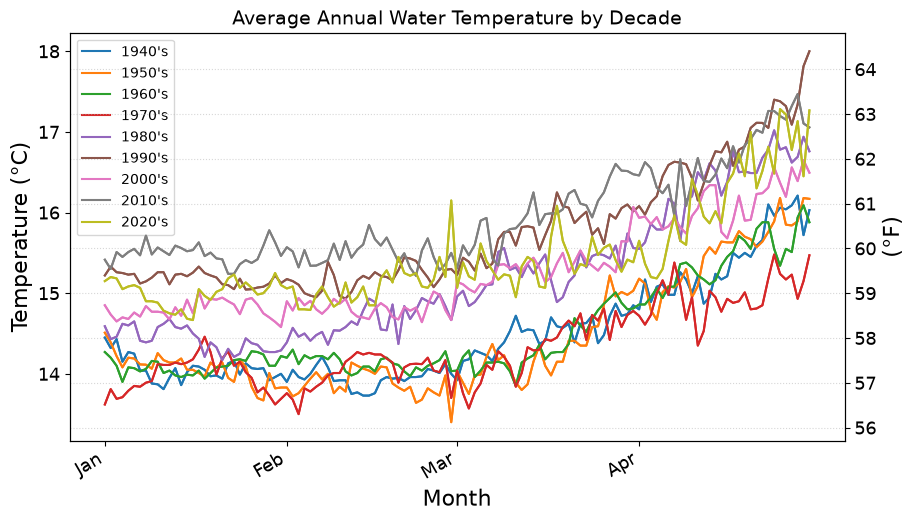

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
first_4 = decade_temps[decade_temps.month < 5]
ax2 = ax.twinx()
for decade, df in first_4.groupby('decade'):
    ax.plot(df.mock_date, df.SURF_TEMP_C, label=decade)
    ax2.plot(df.mock_date, df.temp_f)
ax.legend()
ticks = pd.date_range('2000-01-01', '2000-4-01', freq='MS')
ax.set_xticks(ticks)
ax.tick_params(axis='both', labelsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
fig.autofmt_xdate()
plt.title('Average Annual Water Temperature by Decade', fontsize=14)
ax.set_xlabel('Month', fontsize=16)
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax2.set_ylabel('(\u00b0F)', fontsize=16)
ax2.tick_params(axis='y', labelsize=13)
plt.grid(axis='y', alpha=.5, ls=':')
plt.show()

In [46]:
decade_temps.decade.unique()

<ArrowStringArray>
['1940's', '1950's', '1960's', '1970's', '1980's', '1990's', '2000's',
 '2010's', '2020's']
Length: 9, dtype: str

In [47]:
groups = {
    '1940\'s': '1940\'s - 1970\'s',
    '1950\'s': '1940\'s - 1970\'s',
    '1960\'s': '1940\'s - 1970\'s',
    '1970\'s': '1940\'s - 1970\'s',
    '1980\'s': '1980\'s - 2020\'s',
    '1990\'s': '1980\'s - 2020\'s',
    '2000\'s': '1980\'s - 2020\'s',
    '2010\'s': '1980\'s - 2020\'s',
    '1920\'s': '1980\'s - 2020\'s',
}

In [48]:
decade_temps['multi_decade'] = decade_temps.decade.map(groups)

In [49]:
decade_temps.head(2)

,decade,month,day,SURF_TEMP_C,mock_year,mock_dt_str,mock_date,temp_f,multi_decade
0,1940's,1,1,14.45,2000,2000-1-1,2000-01-01,58.010,1940's - 1970's
1,1940's,1,2,14.32,2000,2000-1-2,2000-01-02,57.776,1940's - 1970's


In [56]:
multi_decade_temps = decade_temps.groupby(['multi_decade', 'month', 'day']).SURF_TEMP_C.mean().reset_index()

In [57]:
multi_decade_temps.head(2)

,multi_decade,month,day,SURF_TEMP_C
0,1940's - 1970's,1,1,14.2125
1,1940's - 1970's,1,2,14.1800


In [58]:
multi_decade_temps['mock_year'] = '2000'
multi_decade_temps['mock_dt_str'] = multi_decade_temps.mock_year + '-' + multi_decade_temps.month.astype(str) + '-' + multi_decade_temps.day.astype(str)
multi_decade_temps['mock_date'] = pd.to_datetime(multi_decade_temps.mock_dt_str, 
                                                 format='%Y-%m-%d'
                                                 )

In [59]:
multi_decade_temps['temp_f'] = c_to_f(multi_decade_temps.SURF_TEMP_C)

In [60]:
multi_decade_temps.head(2)

,multi_decade,month,day,SURF_TEMP_C,mock_year,mock_dt_str,mock_date,temp_f
0,1940's - 1970's,1,1,14.2125,2000,2000-1-1,2000-01-01,57.5825
1,1940's - 1970's,1,2,14.1800,2000,2000-1-2,2000-01-02,57.5240


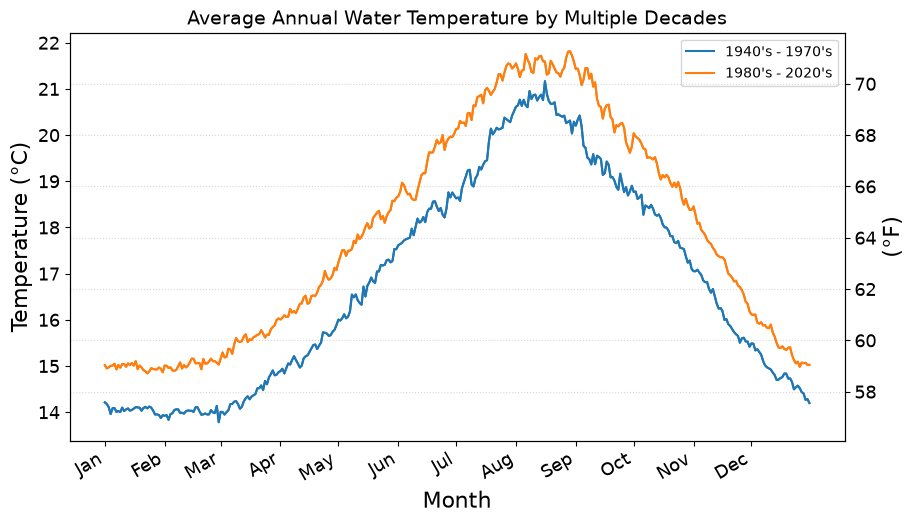

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
for decade, df in multi_decade_temps.groupby('multi_decade'):
    ax.plot(df.mock_date, df.SURF_TEMP_C, label=decade)
    ax2.plot(df.mock_date, df.temp_f)
ax.legend()
ticks = pd.date_range('2000-01-01', '2000-12-01', freq='MS')
ax.set_xticks(ticks)
ax.tick_params(axis='both', labelsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
fig.autofmt_xdate()
plt.title('Average Annual Water Temperature by Multiple Decades', fontsize=14)
ax.set_xlabel('Month', fontsize=16)
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax2.set_ylabel('(\u00b0F)', fontsize=16)
ax2.tick_params(axis='y', labelsize=13)
plt.grid(axis='y', alpha=.5, ls=':')
plt.show()